$\newcommand{\deriv}{\mathrm{d}}$

# 1-Integration 

## 1-1 Intégrale de Riemann

$\begin{align}
\int f \deriv x \approx \sum f_i\Delta x_i
\end{align}$

In [190]:
# librairie
import numpy as np
import matplotlib.pyplot as plt 

In [53]:
x=np.linspace(-np.pi,np.pi,600)
sin=np.sin(x)
cos=np.cos(x)


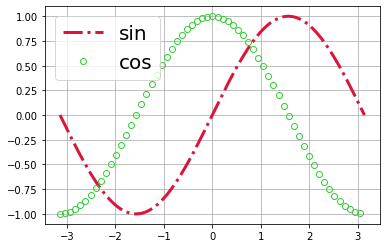

In [54]:
plt.figure()
plt.plot(x,sin,'-.',color='crimson',label='sin',linewidth=3)
plt.plot(x,cos,'o',color='limegreen',label='cos',linewidth=3,markevery=10,markerfacecolor='none')
plt.legend(fontsize=20)
plt.grid()
plt.show()

In [93]:
def integration(x,f,mode='Rect'):
    """
    fonction qui calcul l'intégrale 
    x : array(Nx)
    f : array(Nx)
    mode : Rect ou Trap : string / methode d'integration 
    """

    Nx = len(x)
    # calcul de la première aire 
    F=(x[1]-x[0])*f[0]
    
    Ftab = [F]
    
    for i in range(1,Nx):
        rec_i = (x[i]-x[i-1])*f[i] 
        F+=rec_i # equivalent à F = F + rec_i   
        Ftab.append(F)
        
    return F, np.array(Ftab)


-0.010489457941867777


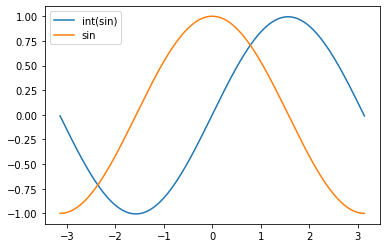

In [98]:
F, primitive = integration(x,cos)
print(F)
plt.figure()
plt.plot(x,primitive,label='int(sin)')
plt.plot(x,cos,label='sin')
plt.legend()
plt.show()

## 1.2 Calcul de surface 
En cartésien:
$\begin{align}
\int \deriv S &= \int_{D_x}\int_{D_y} \deriv x\deriv y \approx \sum\sum \Delta x_i\Delta y_j
\end{align}$

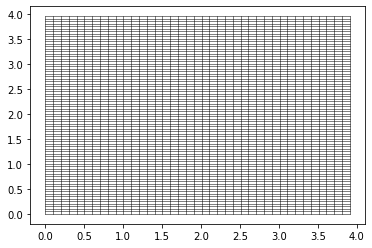

In [191]:
x = np.linspace(0,4,400)
y = np.linspace(0,4,800)

X,Y = np.meshgrid(x,y)
X,Y = X.T,Y .T

ijump, jjump =10,10

plt.figure()
plt.plot(X[::ijump,::jjump],Y[::ijump,::jjump],'-',color='black',linewidth=0.5)
plt.plot(X[::ijump,::jjump].T,Y[::ijump,::jjump].T,'-',color='black',linewidth=0.5)
plt.show()

In [192]:
# x et y sont des arrays 1D tandis que X, Y sont 2D, pour chaque i est associé un j.
# On travaillera forcement X,Y pour des maillage curvilignes. Ici, on peut partie de x, y puisque le maillage est cartésien

print("dim de x, y:")
print(np.shape(x),np.shape(y))
print("-------------------")
print("dim de X, Y:")
print(np.shape(X),np.shape(Y))

dim de x, y:
(400,) (800,)
-------------------
dim de X, Y:
(400, 800) (400, 800)


In [193]:
def calcul_surf(xi,eta):
    """
    Compute Surface based on cartesian grid mesh 
    xi : array(xi)
    eta : array(Ny)
    """
    
    Nx = len(xi)
    Ny = len(eta)
    S = (xi[1]-xi[0])*(y[1]-y[0])
    k=1
    for i in range(1,Nx):
        for j in range(1,Ny):
            rect_ij = (xi[i]-xi[i-1])*(eta[j]-eta[j-1])
            S+=rect_ij
            k+=1
    return S
            


In [187]:
print(calcul_surf(x,y))

16.0000501879606


## 1.2.1 convergence de l'aire

In [194]:
S_tests=[]
N_tests=[]
Lx,Ly = 4,3
for N in range(10,200,10):
    x = np.linspace(0,Lx,N)
    y = np.linspace(0,Ly,N)
    S = calcul_surf(x,y)
    S_tests.append(S)
    N_tests.append(N)
S_tests,N_tests=np.array(S_tests),np.array(N_tests)

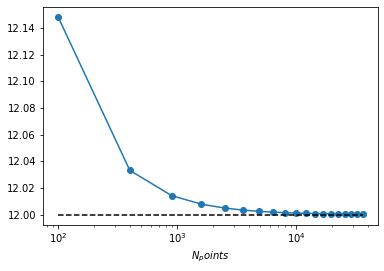

last estimation: 12.000335936843502
convergence error: 0.00033593684350208264


In [197]:
plt.figure()
plt.plot(N_tests**2,S_tests,'-o')
plt.plot(N_tests**2,N_tests*0+Lx*Ly,'--',color='black')
plt.xscale('log')
plt.xlabel('$N_points$')
plt.show()
print('last estimation:', S_tests[-1])
print('convergence error:', S_tests[-1]-Lx*Ly)